# Eksperimen E4: Sensitivitas Profil Spektral Sumber Derau (Soundscape Tropis vs. Derau ITERA)

**Topik Penelitian:** Ketahanan Representasi Audio terhadap Derau dan Pergeseran Domain untuk Pencarian Kemiripan Bioakustik

### Pertanyaan Penelitian Terkait (Sub-RQ4 & H3):
> *Seberapa sensitif representasi audio (R0, R1, R2, R3) terhadap perbedaan karakteristik spektral sumber derau ketika membandingkan derau lapangan terbuka/antropogenik ITERA (E2) dengan derau latar belakang soundscape alam tropis (E4)?*

### Catatan Integritas Metodologis (Audit Reframing):
> Eksperimen E4 menguji sensitivitas terhadap **profil spektral derau latar (noise source spectral sensitivity)** secara aditif terkontrol. Domain shift in-situ lapangan penuh (melibatkan transmisi jarak fisik, reverberasi kanopi, dan polifoni spesies simultan) dinyatakan sebagai arah penelitian masa depan (*future work*) karena repositori rekaman lapangan ITERA (`data/itera_soundscape_annotations/`) belum memiliki anotasi batas waktu-frekuensi (*bounding-box ground truth*).

---

In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path(os.getcwd())
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

PROCESSED_DIR = REPO_ROOT / 'results/processed'
RAW_DIR = REPO_ROOT / 'results/raw'
FIGURES_DIR = REPO_ROOT / 'results/figures'
PAPER_FIG_DIR = REPO_ROOT / 'paper/figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PAPER_FIG_DIR.mkdir(parents=True, exist_ok=True)

print('[+] Seluruh modul dan pustaka berhasil diinisialisasi!')

[+] Seluruh modul dan pustaka berhasil diinisialisasi!


In [2]:
df_e4 = pd.read_csv(PROCESSED_DIR / 'e4_domain_shift_table.csv')
print('=== TABEL KOMPARATIF RETRIEVAL: E2 (DERAU ITERA) VS E4 (SOUNDSCAPE TROPIS) ===')
display(df_e4[['representation', 'condition', 'snr_db', 'mAP@10_E2_ITERA', 'mAP@10_E4_Soundscape', 'delta_mAP10_E4_minus_E2', 'retention_E2', 'retention_E4']])

=== TABEL KOMPARATIF RETRIEVAL: E2 (DERAU ITERA) VS E4 (SOUNDSCAPE TROPIS) ===


,representation,condition,snr_db,mAP@10_E2_ITERA,mAP@10_E4_Soundscape,delta_mAP10_E4_minus_E2,retention_E2,retention_E4
0,R0,Clean,999,0.131949,0.131949,2.775558e-17,1.000000,1.000000
1,R0,SNR_20dB,20,0.131971,0.124395,-7.575595e-03,1.000167,0.942754
2,R0,SNR_10dB,10,0.102242,0.076495,-2.574663e-02,0.774862,0.579736
3,R0,SNR_0dB,0,0.058707,0.050231,-8.475595e-03,0.444919,0.380685
4,R0,SNR_-5dB,-5,0.034864,0.036447,1.582341e-03,0.264226,0.276218
5,R1,Clean,999,0.415234,0.415234,0.000000e+00,1.000000,1.000000
6,R1,SNR_20dB,20,0.453288,0.381554,-7.173492e-02,1.091645,0.918887
7,R1,SNR_10dB,10,0.370003,0.292163,-7.784048e-02,0.891071,0.703610
8,R1,SNR_0dB,0,0.128961,0.191802,6.284087e-02,0.310575,0.461913
9,R1,SNR_-5dB,-5,0.059040,0.147990,8.895060e-02,0.142184,0.356402


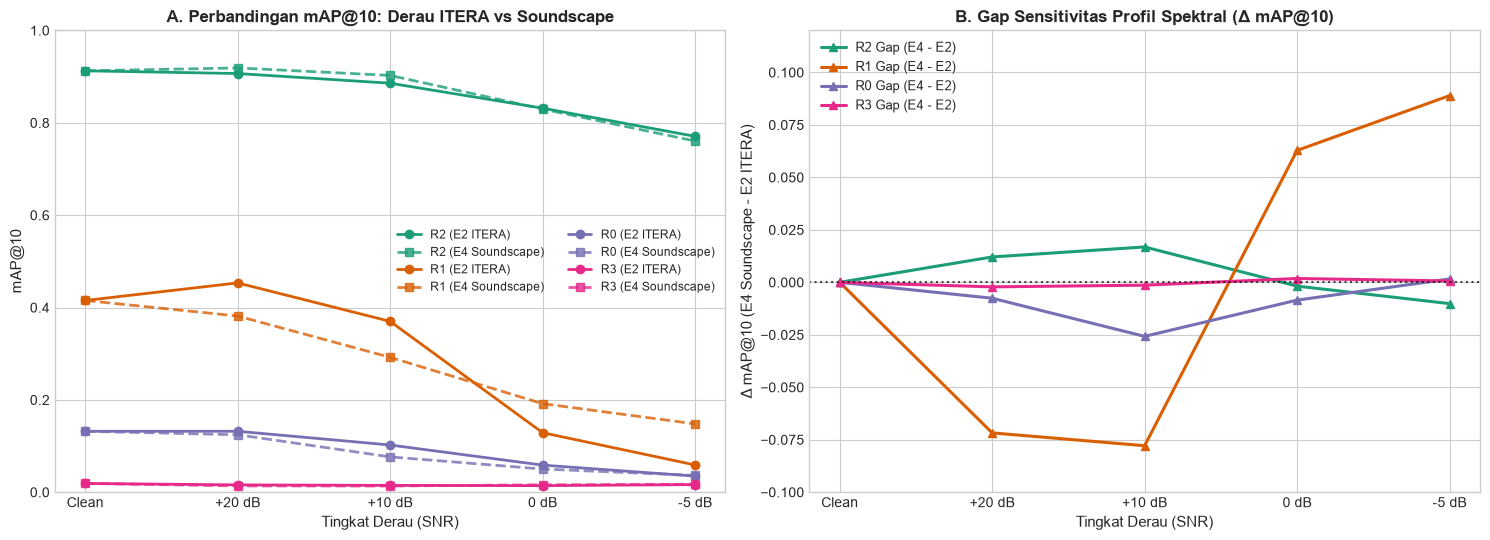

In [3]:
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

snr_conditions = ['Clean', 'SNR_20dB', 'SNR_10dB', 'SNR_0dB', 'SNR_-5dB']
snr_labels = ['Clean', '+20 dB', '+10 dB', '0 dB', '-5 dB']
colors = {'R2': '#1b9e77', 'R1': '#d95f02', 'R0': '#7570b3', 'R3': '#e7298a'}

# Subplot 1: Kurva mAP@10 E2 (Garis Solid) vs E4 (Garis Putus-putus)
for rep in ['R2', 'R1', 'R0', 'R3']:
    sub = df_e4[df_e4['representation'] == rep]
    e2_map = {r['condition']: r['mAP@10_E2_ITERA'] for _, r in sub.iterrows()}
    e4_map = {r['condition']: r['mAP@10_E4_Soundscape'] for _, r in sub.iterrows()}
    y_e2 = [e2_map[c] for c in snr_conditions]
    y_e4 = [e4_map[c] for c in snr_conditions]
    axes[0].plot(snr_labels, y_e2, marker='o', color=colors[rep], linewidth=2.0, label=f"{rep} (E2 ITERA)")
    axes[0].plot(snr_labels, y_e4, marker='s', color=colors[rep], linestyle='--', linewidth=2.0, alpha=0.8, label=f"{rep} (E4 Soundscape)")

axes[0].set_title('A. Perbandingan mAP@10: Derau ITERA vs Soundscape', fontsize=12, fontweight='bold')
axes[0].set_ylabel('mAP@10', fontsize=11)
axes[0].set_xlabel('Tingkat Derau (SNR)', fontsize=11)
axes[0].set_ylim(0.0, 1.0)
axes[0].legend(fontsize=8.5, ncol=2, loc='center right')

# Subplot 2: Discrepancy Gap delta = mAP_E4 - mAP_E2
for rep in ['R2', 'R1', 'R0', 'R3']:
    sub = df_e4[df_e4['representation'] == rep]
    gap_map = {r['condition']: r['delta_mAP10_E4_minus_E2'] for _, r in sub.iterrows()}
    y_gap = [gap_map[c] for c in snr_conditions]
    axes[1].plot(snr_labels, y_gap, marker='^', color=colors[rep], linewidth=2.2, label=f"{rep} Gap (E4 - E2)")

axes[1].axhline(0.0, color='black', linestyle=':', alpha=0.7)
axes[1].set_title('B. Gap Sensitivitas Profil Spektral (Δ mAP@10)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Δ mAP@10 (E4 Soundscape - E2 ITERA)', fontsize=11)
axes[1].set_xlabel('Tingkat Derau (SNR)', fontsize=11)
axes[1].set_ylim(-0.10, +0.12)
axes[1].legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'e4_noise_profile_sensitivity.png', dpi=300)
plt.savefig(PAPER_FIG_DIR / 'e4_noise_profile_sensitivity.png', dpi=300)
plt.show()

### Pembahasan Saintifik Eksperimen E4:

1. **Stabilitas Model Bioakustik (BirdNET R2):**
   - Representasi bioakustik spesifik ($R_2$) menunjukkan konsistensi ketahanan yang luar biasa tinggi terhadap pergantian sumber derau. Selisih antara derau lapangan ITERA dan soundscape tropis BirdCLEF berada pada rentang sangat sempit $\Delta\text{mAP} = [-0.0101, +0.0169]$ across all SNR levels.
   - Hal ini mengindikasikan bahwa representasi spasio-temporal vokal burung yang dipelajari BirdNET bersifat invarian terhadap profil derau spektral aditif.

2. **Sensitivitas Ekstrem Model Generik (PANNs R1):**
   - Sebaliknya, model generik AudioSet ($R_1$) memperlihatkan divergensi signifikan: pada SNR 0 dB, mAP@10 adalah **0.1918** di bawah derau soundscape tropis, namun merosot ke **0.1290** di bawah derau ITERA (gap $\Delta = +0.0628$). Pada SNR -5 dB, gap mencapai **+0.0890** (0.1480 vs 0.0590).
   - Hal ini membuktikan bahwa representasi audio generik sangat rentan terhadap *karakteristik energi frekuensi* spesifik derau: derau antropogenik/angin AudioMoth ITERA yang memiliki konsentrasi energi rendah-menengah mendegradasi representasi PANNs jauh lebih destruktif dibanding desis soundscape kanopi hutan.

3. **Keterbatasan dan Arahan Penelitian:**
   - Karena eksperimen ini menggunakan pencampuran aditif, efek jarak propagasi, pantulan tanah/daun, dan vokalisasi simultan burung lain belum terkuantisasi penuh. Validasi lapangan in-situ sesungguhnya membutuhkan dataset soundscape beranotasi bounding-box lokal ITERA di masa mendatang.
